<a href="https://colab.research.google.com/github/Bica-plus-equals/RE-Investments-Decarbonisation/blob/main/Renewable_Energy_Markets_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project is a comprehensive analysis focused on modeling renewable energy technologies to assess their profitability and sustainability, particularly in the context of future decarbonization scenarios and policies.


#Overview

The core of this work involves modeling various renewable energy technologies. It uses financial data such as Capital Expenditure (CAPEX), Operational Expenditure (OPEX), project lifetime, and estimated discount rates to predict the profitability of different technologies. Additionally, it includes a sustainability assessment that considers future decarbonization pathways and policy impacts.

#New Model

###Data Loading and Cleaning

In [ ]:
#Load file from drive
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path='/content/drive/MyDrive/IEA-NEAProjectedCostsofGeneratingElectricity2020-Datafile.xlsx'
xls = pd.ExcelFile(file_path)

iea_data = pd.read_excel(xls, sheet_name=xls.sheet_names[2],header=[3,4],skipfooter=1)
iea_data = iea_data.iloc[:,1:]
#iea_data - iea_data.dropna()
print(iea_data)

                       Technology Number of plants / countries  \
               Unnamed: 1_level_1           Unnamed: 2_level_1   
0                           ACAES                        1 / 1   
1             Lithium-ion battery                        4 / 4   
2                         Biomass                        4 / 3   
3                   Biomass (CHP)                        5 / 2   
4                            Coal                       11 / 6   
5                     Coal (CCUS)                        4 / 2   
6                      Coal (CHP)                        1 / 1   
7                       Fuel cell                        4 / 2   
8                      Gas (CCGT)                      16 / 11   
9                Gas (CCGT, CCUS)                        2 / 2   
10                Gas (CCGT, CHP)                        2 / 2   
11          Gas (OCGT/int. comb.)                        8 / 5   
12     Gas (OCGT/int. comb., CHP)                        3 / 3   
13        

In [ ]:
iea_data.columns
#flatten labels
iea_data.columns = [' '.join(col) for col in iea_data.columns]
print(iea_data.columns)

Index(['Technology Unnamed: 1_level_1',
       'Number of plants / countries Unnamed: 2_level_1',
       'Net capacity (MWe) Min', 'Net capacity (MWe) Mean',
       'Net capacity (MWe) Median', 'Net capacity (MWe) Max',
       'Overnight costs (USD/kWe) Min', 'Overnight costs (USD/kWe) Mean',
       'Overnight costs (USD/kWe) Median', 'Overnight costs (USD/kWe) Max',
       'Capacity Factor Unnamed: 11_level_1'],
      dtype='object')


###Data Analysis: Calculate OPEX, Revenue, Emissions.

In [ ]:
#Rename some labels
iea_data = iea_data.rename(columns={
    'Technology Unnamed: 1_level_1' : 'Technology',
    'Number of plants / countries Unnamed: 2_level_1': 'Number of plants / countries'
})

In [ ]:
print(iea_data['Technology'])

#Add OPEX factors (generated from ChatGPT)

opex_share = {
    "ACAES": 0.03,
    "Lithium-ion battery": 0.02,
    "Biomass": 0.08,
    "Biomass (CHP)": 0.09,
    "Coal": 0.06,
    "Coal (CCUS)": 0.08,
    "Coal (CHP)": 0.07,
    "Fuel cell": 0.04,
    "Gas (CCGT)": 0.04,
    "Gas (CCGT, CCUS)": 0.06,
    "Gas (CCGT, CHP)": 0.05,
    "Gas (OCGT/int. comb.)": 0.03,
    "Gas (OCGT/int. comb., CHP)": 0.04,
    "Geothermal": 0.04,
    "Hydro (reservoir, >= 5 MW)": 0.02,
    "Hydro (reservoir, < 5 MW)": 0.02,
    "Hydro (run of river, >= 5 MW)": 0.015,
    "Hydro (run of river, < 5 MW)": 0.015,
    "Lignite": 0.06,
    "Lignite (CCUS)": 0.08,
    "Lignite (CHP)": 0.07,
    "Nuclear": 0.03,
    "Nuclear (LTO)": 0.025,
    "Pumped storage": 0.015,
    "Solar PV (floating)": 0.015,
    "Solar PV (utility scale)": 0.01,
    "Solar PV (commercial)": 0.012,
    "Solar PV (residential)": 0.015,
    "Solar thermal (CSP)": 0.03,
    "Offshore wind": 0.025,
    "Onshore wind (>= 1 MW)": 0.02,
    "Onshore wind (< 1 MW)": 0.02
}

#Introduce in dataframe
iea_data['OPEX_factor'] = iea_data['Technology'].map(opex_share)

0                             ACAES
1               Lithium-ion battery
2                           Biomass
3                     Biomass (CHP)
4                              Coal
5                       Coal (CCUS)
6                        Coal (CHP)
7                         Fuel cell
8                        Gas (CCGT)
9                  Gas (CCGT, CCUS)
10                  Gas (CCGT, CHP)
11            Gas (OCGT/int. comb.)
12       Gas (OCGT/int. comb., CHP)
13                       Geothermal
14       Hydro (reservoir, >= 5 MW)
15        Hydro (reservoir, < 5 MW)
16    Hydro (run of river, >= 5 MW)
17     Hydro (run of river, < 5 MW)
18                          Lignite
19                   Lignite (CCUS)
20                    Lignite (CHP)
21                          Nuclear
22                    Nuclear (LTO)
23                   Pumped storage
24              Solar PV (floating)
25         Solar PV (utility scale)
26            Solar PV (commercial)
27           Solar PV (resid

In [ ]:
iea_data['OPEX (USD/kWe) Min'] = iea_data['Overnight costs (USD/kWe) Min'] * iea_data['OPEX_factor']
iea_data['OPEX (USD/kWe) Max'] = iea_data['Overnight costs (USD/kWe) Max'] * iea_data['OPEX_factor']
iea_data['OPEX (USD/kWe) Mean'] = iea_data['Overnight costs (USD/kWe) Mean'] * iea_data['OPEX_factor']
iea_data['OPEX (USD/kwE) Median'] = iea_data['Overnight costs (USD/kWe) Median'] * iea_data['OPEX_factor']

print(iea_data.iloc[3])


Technology                             Biomass (CHP)
Number of plants / countries                   5 / 2
Net capacity (MWe) Min                         0.415
Net capacity (MWe) Mean                     130.0575
Net capacity (MWe) Median                   130.0575
Net capacity (MWe) Max                         357.6
Overnight costs (USD/kWe) Min             2537.81342
Overnight costs (USD/kWe) Mean           4689.184397
Overnight costs (USD/kWe) Median         4689.184397
Overnight costs (USD/kWe) Max             6545.46079
Capacity Factor Unnamed: 11_level_1              NaN
OPEX_factor                                     0.09
OPEX (USD/kWe) Min                        228.403208
OPEX (USD/kWe) Max                        589.091471
OPEX (USD/kWe) Mean                       422.026596
OPEX (USD/kwE) Median                     422.026596
Name: 3, dtype: object


To model electricity revenues, we'll use an annual electricity price. This will add in uncertainty, but we will run a sensitivity analysis of 20-30% which will overcome this issue. The revenue formula is:

$$Revenue = MWe * 8760 * CF * Price$$

We have capacity data in MWe, 8760 are the hours in a year, CF is capacity factor. The hours are needed to convert from power to energy production per year.

For our purpouses of long-term horizons, we use the average electricity price over Europe ~  €0.2896/kWh = **$0.31/kWh = $310/MWh** (Ref: [Eurostat](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Electricity_price_statistics))

The capacity factors are generated from ChatGPT for this particular study. Quick fact-checking shows that the generated data is off by about 2%. We keep this for prototyping, and plan to change it in future versions to increase accuracy.



In [ ]:
#Get energy from power

#Approximated Capacity Factors from IEA 2020 report
capacity_factors = {
    "ACAES": 0.45,
    "Lithium-ion battery": 0.15,
    "Biomass": 0.75,
    "Biomass (CHP)": 0.80,
    "Coal": 0.70,
    "Coal (CCUS)": 0.65,
    "Coal (CHP)": 0.75,
    "Fuel cell": 0.85,
    "Gas (CCGT)": 0.55,
    "Gas (CCGT, CCUS)": 0.50,
    "Gas (CCGT, CHP)": 0.60,
    "Gas (OCGT/int. comb.)": 0.10,
    "Gas (OCGT/int. comb., CHP)": 0.15,
    "Geothermal": 0.85,
    "Hydro (reservoir, >= 5 MW)": 0.45,
    "Hydro (reservoir, < 5 MW)": 0.40,
    "Hydro (run of river, >= 5 MW)": 0.50,
    "Hydro (run of river, < 5 MW)": 0.45,
    "Lignite": 0.75,
    "Lignite (CCUS)": 0.70,
    "Lignite (CHP)": 0.80,
    "Nuclear": 0.85,
    "Nuclear (LTO)": 0.90,
    "Pumped storage": 0.20,
    "Solar PV (floating)": 0.18,
    "Solar PV (utility scale)": 0.20,
    "Solar PV (commercial)": 0.15,
    "Solar PV (residential)": 0.12,
    "Solar thermal (CSP)": 0.45,
    "Offshore wind": 0.45,
    "Onshore wind (>= 1 MW)": 0.35,
    "Onshore wind (< 1 MW)": 0.30
}

iea_data['Capacity Factor'] = iea_data['Technology'].map(capacity_factors)

iea_data['Energy (MWh) Max'] = iea_data['Net capacity (MWe) Max'] * 8760 * iea_data['Capacity Factor']
iea_data['Energy (MWh) Min'] = iea_data['Net capacity (MWe) Min'] * 8760 * iea_data['Capacity Factor']
iea_data['Energy (MWh) Mean'] = iea_data['Net capacity (MWe) Mean'] * 8760 * iea_data['Capacity Factor']
iea_data['Energy (MWh) Median'] = iea_data['Net capacity (MWe) Median'] * 8760 * iea_data['Capacity Factor']

iea_data['Revenue ($) Max'] = iea_data['Energy (MWh) Max'] * 310
iea_data['Revenue ($) Min'] = iea_data['Energy (MWh) Min'] * 310
iea_data['Revenue ($) Mean'] = iea_data['Energy (MWh) Mean'] * 310
iea_data['Revenue ($) Median'] = iea_data['Energy (MWh) Median'] * 310


In [ ]:
iea_data.iloc[3]

,3
Technology,Biomass (CHP)
Number of plants / countries,5 / 2
Net capacity (MWe) Min,0.415
Net capacity (MWe) Mean,130.0575
Net capacity (MWe) Median,130.0575
Net capacity (MWe) Max,357.6
Overnight costs (USD/kWe) Min,2537.81342
Overnight costs (USD/kWe) Mean,4689.184397
Overnight costs (USD/kWe) Median,4689.184397
Overnight costs (USD/kWe) Max,6545.46079


##ROI timeline

In [ ]:
def discounting(object, year, discount_rate=0.07):
  factor  = (1 / (1 + discount_rate)) ** year
  return object * factor

In [ ]:
iea_data.columns

Index(['Technology', 'Number of plants / countries', 'Net capacity (MWe) Min',
       'Net capacity (MWe) Mean', 'Net capacity (MWe) Median',
       'Net capacity (MWe) Max', 'Overnight costs (USD/kWe) Min',
       'Overnight costs (USD/kWe) Mean', 'Overnight costs (USD/kWe) Median',
       'Overnight costs (USD/kWe) Max', 'Capacity Factor Unnamed: 11_level_1',
       'OPEX_factor', 'OPEX (USD/kWe) Min', 'OPEX (USD/kWe) Max',
       'OPEX (USD/kWe) Mean', 'OPEX (USD/kwE) Median', 'Capacity Factor',
       'Energy (MWh) Max', 'Energy (MWh) Min', 'Energy (MWh) Mean',
       'Energy (MWh) Median', 'Revenue ($) Max', 'Revenue ($) Min',
       'Revenue ($) Mean', 'Revenue ($) Median'],
      dtype='object')

In [ ]:
iea_data['Initial CAPEX'] = iea_data['Overnight costs (USD/kWe) Mean'] * 1000 * iea_data['Net capacity (MWe) Mean']
iea_data['Annual Cashflow'] = iea_data['Revenue ($) Mean'] - iea_data['OPEX (USD/kWe) Mean'] *1000 *iea_data['Net capacity (MWe) Mean']

#dcf / npv
discount_rate = 0.07
years = 20

#Calculate the discount factors per year
discount_factors = np.array([
    1 / ((1+ discount_rate) ** t)
    for t in range(1, years+1)
])

iea_data['NPV 20yr'] = iea_data['Annual Cashflow'].apply(
    lambda cf: np.sum(cf * discount_factors)
) - iea_data['Initial CAPEX']

In [ ]:
import matplotlib.pyplot as plt

#Time-series generation
cashflow_matrix = iea_data['Annual Cashflow'].values[:,None] * np.ones(years)
#cashflow_matrix.shape

discounted_cf_timeseries = cashflow_matrix * discount_factors
#discounted_cf_timeseries.shape

cumu_npv = np.cumsum(discounted_cf_timeseries, axis=1) - iea_data['Initial CAPEX'].values[:,None]
#cumu_npv.shape

# payback_yr = np.argmax(cumu_npv>0, axis=1)


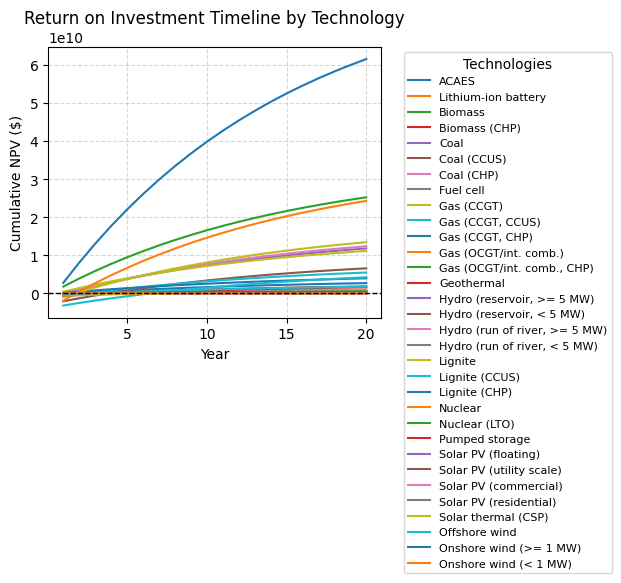

In [ ]:
#Plot ROI timeline
import matplotlib.pyplot as plt
import numpy as np

years = np.arange(1, 21)

plt.figure()

# plot a few technologies
for i in range(32):
    plt.plot(
        years,
        cumu_npv[i],
        label=iea_data["Technology"].iloc[i]
    )

# break-even line
plt.axhline(0, linestyle='--', color='black', linewidth=1)

plt.xlabel("Year")
plt.ylabel("Cumulative NPV ($)")
plt.title("Return on Investment Timeline by Technology")

plt.grid(True, linestyle='--', alpha=0.5)

# legend OUTSIDE plot
plt.legend(
    title="Technologies",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

#(Updating in Progress)

##Marginal Abatement Cost Curve (MACC) Analysis



The project utilizes Marginal Abatement Cost Curves (MACC) to identify the most cost-effective ways to reduce CO2 emissions. Key elements of this analysis include:

- **Technology**: A range of renewable technologies like Solar PV, Onshore Wind, Biomass, Nuclear, and Carbon Capture Usage and Storage (CCUS).
- **Segment Type**: Technologies are divided into different segments based on their cost and technological maturity.
- **Segment Potential**: The potential CO2 abatement for each segment.
- **Marginal Cost**: The cost associated with abating an additional unit of CO2.
- **Cumulative Potential**: The total emissions abated by combining various technology segments.

The MACC curve visually represents the cost of abating CO2 against the cumulative abatement potential, helping to prioritize investments.

In [ ]:
import pandas as pd

#Load Data
MACC_data = pd.read_csv('/content/illustrative_macc_renewables.csv')

#Color code by technology for plotting
colors = {
    'Solar PV': 'orange',
    'Onshore Wind': 'blue',
    'Smart grids / flexibility': 'green',
    'Biomass': 'red',
    'HVDC (long-distance transmission)': 'pink',
    'Batteries (storage)': 'purple',
    'Nuclear': 'yellow',
    'CCUS (power/industry)': 'brown'
}

MACC_data['color'] = MACC_data['technology'].map(colors)

print(MACC_data.columns)


Index(['technology', 'segment', 'segment_potential_MtCO2_per_year',
       'marginal_cost_USD_per_tCO2', 'cumulative_potential_MtCO2_per_year',
       'color'],
      dtype='object')


In [ ]:
#MACC_data

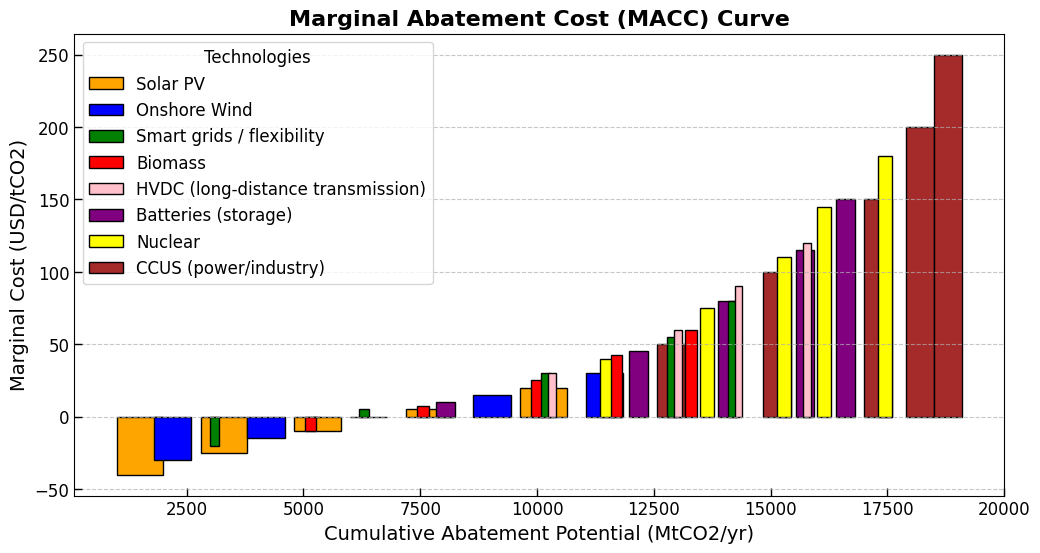

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Sort by cost for MACC and compute cumulative potential
MACC_data = MACC_data.sort_values('marginal_cost_USD_per_tCO2') #sort by cost
MACC_data['cumulative_potential_MtCO2_per_year'] = MACC_data['segment_potential_MtCO2_per_year'].cumsum() #calculate cumulative potential

#Plot MACC curve
plt.figure(figsize=(12,6))

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12})

for _, row in MACC_data.iterrows():
    plt.bar(row['cumulative_potential_MtCO2_per_year'],
            row['marginal_cost_USD_per_tCO2'],
            width=row['segment_potential_MtCO2_per_year'],
            color=row['color'],
            align='edge',
            edgecolor='black'
            )

plt.title('Marginal Abatement Cost (MACC) Curve', fontsize=16, weight='bold')
plt.xlabel('Cumulative Abatement Potential (MtCO2/yr)', fontsize=14)
plt.ylabel('Marginal Cost (USD/tCO2)', fontsize=14)

#Create legend from the colors dictionary
legend_elements = [Patch(facecolor=color, edgecolor='black',label=tech)
                    for tech, color in colors.items()]
plt.legend(handles=legend_elements, title='Technologies')

#Ticks inward
plt.tick_params(axis='both', direction='in', length=6, width=1)

#Add a coarse grid
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.8, alpha=0.7)

#Show plot
plt.show()


##Investment Costs and Levelized Cost of Abatement (LCCA)


Detailed financial parameters for each technology are defined, including:

- **CAPEX**: Capital expenditure per MtCO2.
- **OPEX**: Operating expenditure per year.
- **Lifetime**: The operational lifespan of the technology.
- **Discount Rate**: Used to evaluate the present value of future cash flows.

These parameters are used to calculate the **Annualized CAPEX** and **Discounted OPEX**. From these, the **Levelized Cost of Abatement (LCOA)** is derived, representing the average cost of abating one tonne of CO2 over the project's lifetime.

In [ ]:
# Financial parameters dictionary ($ in Millions)
financial_params = {
    'Solar PV': {'CAPEX': 800, 'OPEX': 20, 'lifetime': 25, 'discount_rate': 0.07},
    'Onshore Wind': {'CAPEX': 700, 'OPEX': 15, 'lifetime': 25, 'discount_rate': 0.07},
    'Smart grids / flexibility': {'CAPEX': 500, 'OPEX': 10, 'lifetime': 20, 'discount_rate': 0.07},
    'Biomass': {'CAPEX': 900, 'OPEX': 30, 'lifetime': 25, 'discount_rate': 0.07},
    'HVDC (long-distance transmission)': {'CAPEX': 600, 'OPEX': 5, 'lifetime': 30, 'discount_rate': 0.07},
    'Batteries (storage)': {'CAPEX': 400, 'OPEX': 10, 'lifetime': 15, 'discount_rate': 0.07},
    'Nuclear': {'CAPEX': 5000, 'OPEX': 100, 'lifetime': 40, 'discount_rate': 0.07},
    'CCUS (power/industry)': {'CAPEX': 2000, 'OPEX': 50, 'lifetime': 25, 'discount_rate': 0.07}
}

#Calculate financial parameters
MACC_data['CAPEX_USD_per_MtCO2']= MACC_data['technology'].map(lambda x: financial_params[x]['CAPEX'])
MACC_data['OPEX_USD_per_year']= MACC_data['technology'].map(lambda x: financial_params[x]['OPEX'])
MACC_data['lifetime_years']= MACC_data['technology'].map(lambda x: financial_params[x]['lifetime'])
MACC_data['discount_rate'] = MACC_data['technology'].map(lambda x: financial_params[x]['discount_rate'])


In [ ]:
#Discounted OPEX
MACC_data['PV_OPEX_USD_per_MtCO2'] = MACC_data['OPEX_USD_per_year'] * (1 / (1 + MACC_data['discount_rate']) ** MACC_data['lifetime_years'])

#Total (YEARLY) cost is CAPEX + OPEX
MACC_data['total_cost_USD_per_MtCO2_per_year']  = MACC_data['CAPEX_USD_per_MtCO2'] + MACC_data['PV_OPEX_USD_per_MtCO2']

#Levelised Cost of Abatement
MACC_data['LCOA_USD_per_tCO2'] = MACC_data['total_cost_USD_per_MtCO2_per_year'] / (MACC_data['segment_potential_MtCO2_per_year'])


In [ ]:
#Data Ordering
MACC_data = MACC_data.sort_values('technology')
MACC_data['cumulative_potential_MtCO2_per_year'] = MACC_data['segment_potential_MtCO2_per_year'].cumsum()

# tech_grouped = MACC_data.groupby('technology').agg(
#     {'segment_potential_MtCO2_per_year' : 'sum',
#      'LCOA_USD_per_tCO2' : 'mean',
#      'color' : 'first'}).reset_index()


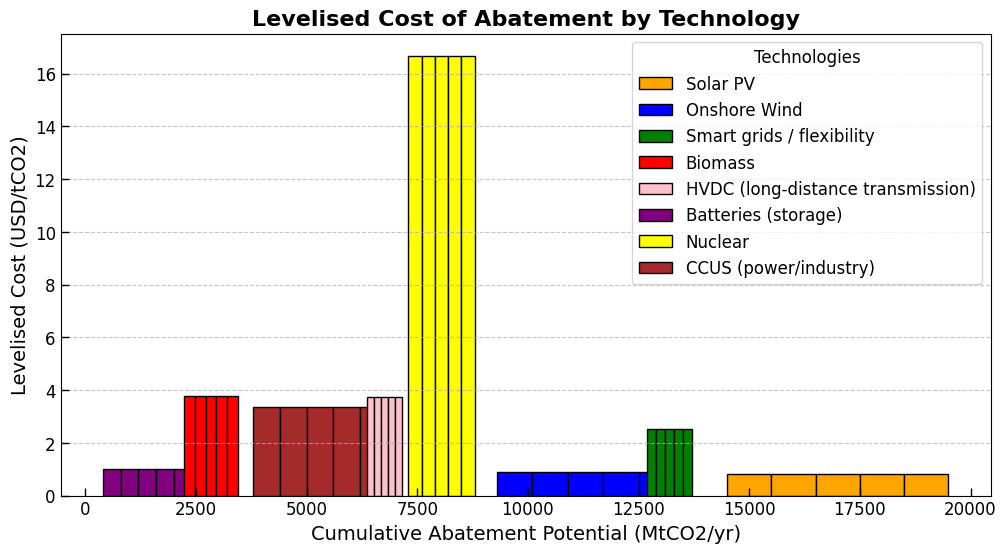

In [ ]:
#Plot
plt.figure(figsize=(12,6))

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12})

for _, row in MACC_data.iterrows():
    plt.bar(row['cumulative_potential_MtCO2_per_year'],
            row['LCOA_USD_per_tCO2'],
            width=row['segment_potential_MtCO2_per_year'],
            color=row['color'],
            align='edge',
            edgecolor='black'
            )

plt.title('Levelised Cost of Abatement by Technology', fontsize=16, weight='bold')
plt.xlabel('Cumulative Abatement Potential (MtCO2/yr)', fontsize=14)
plt.ylabel('Levelised Cost (USD/tCO2)', fontsize=14)

#Create legend from the colors dictionary
legend_elements = [Patch(facecolor=color, edgecolor='black',label=tech)
                    for tech, color in colors.items()]
plt.legend(handles=legend_elements, title='Technologies')

#Ticks inward
plt.tick_params(axis='both', direction='in', length=6, width=1)

#Add a coarse grid
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.8, alpha=0.7)

#Show plot
plt.show()

##Investment Returns Timeline


This section analyzes the cash flow of investments over time. By considering annual revenues (driven by carbon prices) and annual costs (OPEX + annualized CAPEX), the project models the cumulative cash flow for each technology. This helps in understanding the timeline for investment returns and profitability.

###Infer Capacity from the Emissions of the plant
The emission factor is based on the technology being displaced, allowing us to estimate how much fossil fuel capacity corresponds to a given amount of emissions abated. This effectively determines the capacity being replaced and is treated as a constant assumption across all technologies when we assume fossil fuels are displaced. Coal has an emission factor of about 1 tCO₂/MWh, while gas is around 0.45 tCO₂/MWh (both taken at the higher end of their ranges). Based on this, we approximate a representative emission factor of 0.5 tCO₂/MWh.


$Capacity\ (\text{MW}) = \frac{\text{Avoided emissions }(\text{tCO}_2/\text{yr})}{\text{Emission factor }(\text{tCO}_2/\text{MWh}) \cdot \text{C.F.} \cdot 8760}$


In [ ]:
#Introduce Capacity Factor estimated data
capacity_factors = {
    'Solar PV': 0.18 ,
    'Onshore Wind': 0.32,
    'Smart grids / flexibility': None,
    'Biomass': 0.80 ,
    'HVDC (long-distance transmission)': None,
    'Batteries (storage)': None,
    'Nuclear': 0.90,
    'CCUS (power/industry)': 0.85}

MACC_data['capacity_factor'] = MACC_data['technology'].map(capacity_factors)

#Infer Capacity from Abated Emissions, using the assumptions.
MACC_data['capacity_MW'] = MACC_data['segment_potential_MtCO2_per_year'] * 10**6 / (0.5 * MACC_data['capacity_factor'] * 8760)

**Note:** when looking at capacity, we realise that our abatement input size was that equivalent to a global scale, not an individual solar project. Need to improve or replace input data.


In [ ]:
#print(MACC_data[['technology', 'capacity_MW','capacity_factor']])

###Calculate Revenue from Generation

$\text{Revenue} = \text{Capacity} * \text{CF} * 8760 * \text{Electricity Price}$

Price Assumption:
- Conservative: £50 / MWh
- **Mid: £80 / MWh**
- High: £100+ / MWh



In [ ]:
#Revenue
MACC_data['revenue_per_year'] = MACC_data['capacity_MW'] * MACC_data['capacity_factor'] * 8760 * 80
MACC_data['revenue_per_year']

,revenue_per_year
21,NaN
35,NaN
32,NaN
27,NaN
12,NaN
11,3.840000e+10
20,3.840000e+10
25,3.840000e+10
6,3.840000e+10
15,3.840000e+10


In [ ]:
MACC_data.columns

Index(['technology', 'segment', 'segment_potential_MtCO2_per_year',
       'marginal_cost_USD_per_tCO2', 'cumulative_potential_MtCO2_per_year',
       'color', 'CAPEX_USD_per_MtCO2', 'OPEX_USD_per_year', 'lifetime_years',
       'discount_rate', 'PV_OPEX_USD_per_MtCO2',
       'total_cost_USD_per_MtCO2_per_year', 'LCOA_USD_per_tCO2',
       'capacity_factor', 'capacity_MW', 'revenue_per_year'],
      dtype='object')

###Model Financial Metrics

In [ ]:
# Discounting Function
def discounting(object, discount_rate, year):
  factor  = (1 / (1 + discount_rate)) ** year
  return object * factor

In [ ]:
#DCF model
import numpy as np
import pandas as pd

# Time horizon (max lifetime across technologies)
max_years = MACC_data['lifetime_years'].max()

# Initialize cumulative cash flow dictionary
discounted_cash_flows = {}

for _, row in MACC_data.iterrows():
    tech_name = row['technology']
    lifetime = int(row['lifetime_years'])
    r = row['discount_rate']

    #Upfront CAPEX
    capex_total = row['CAPEX_USD_per_MtCO2']

    #Annual revenue and costs
    annual_revenue = row['revenue_per_year']
    annual_opex = row['OPEX_USD_per_year']
    net_cf = annual_revenue - annual_opex

    #Initialize cash flow time series
    cf = np.zeros(max_years)
    cf[0] = -capex_total

    #Year timeline
    for t in range(1, lifetime):
      cf[t] = net_cf #assumes constant revenue and opex

    #Discounted cash flow
    discounted_cf = np.array([discounting(cf[t], r, t) for t in range(len(cf))])

    #Cumulative DCF for payback/ROI timeline
    #Eliminate this to get net yearly cash flows
    cumulative_dcf = np.cumsum(discounted_cf)
    discounted_cash_flows[tech_name] = cumulative_dcf

    #Optional
    #IRR
    # irr = np.irr(cf)
    # irr_results[tech_name] = irr

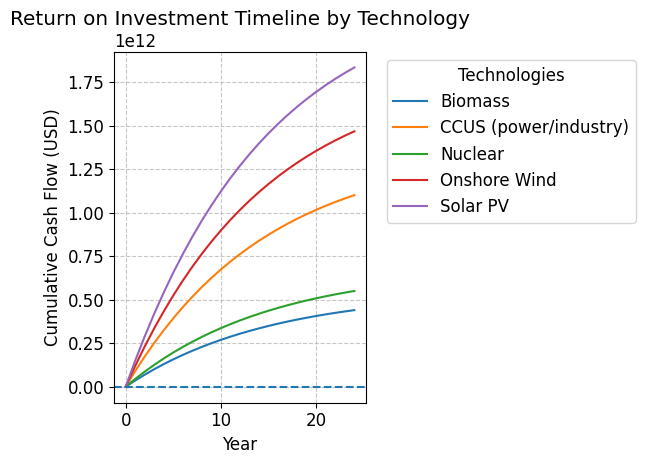

In [ ]:
#ROI timeline
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

for column in dcf_df.columns:
    plt.plot(dcf_df.index, dcf_df[column], label=column)

plt.axhline(0, linestyle ='--') #break-even line

plt.xlabel('Year')
plt.ylabel('Cumulative Cash Flow (USD)')
plt.title('Return on Investment Timeline by Technology')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Technologies', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()





In [ ]:
#Cleaning
dcf_df = pd.DataFrame(discounted_cash_flows)
dcf_df = dcf_df.drop(columns=['Batteries (storage)',
                              'HVDC (long-distance transmission)',
                              'Smart grids / flexibility'])
dcf_df = dcf_df.iloc[:25] #keep years 0 to 24

#dcf_df

####**Note** Unrealistic values (input values were unrealistic)

##Market Influences


The project considers dynamic market conditions that can influence ROI, such as:

- **Carbon Price Increases**: Simulating scenarios where carbon prices escalate over time.
- **Dynamic CAPEX**: Accounting for technology learning rates, where CAPEX decreases over time (e.g., as seen in solar PV).
- **Policy Incentives**: Evaluating the impact of subsidies on effective CAPEX.

In [ ]:
#Carbon Price Increases
carbon_price = 50 # $50
#how do you store increased carbon price as it increases with time?


#Dynamic CAPEX
learning_rate = 0.1 #10%
#is this even relevant for one project?

#Subsidy
subsidy_fraction = 0.25 #25%
#this should be applied at the upfront investment CAPEX[0]

#Main question: how do I store time values?


##Monte Carlo Sensitivity Analysis


A crucial part of the project is the Monte Carlo simulation, which assesses the sensitivity of profitability to uncertainties in key variables. It involves:

- **Sampling Variables**: Randomly sampling CAPEX factors, carbon prices, and discount rates within defined distributions.
- **Vectorized Calculations**: Performing LCOA and revenue calculations for thousands of iterations.
- **Distribution Analysis**: Examining the distribution of LCOA and revenue for each technology segment.
- **Profitability Probability**: Calculating the probability of a technology being profitable (LCOA < 0) and how this probability changes under different carbon price scenarios (low, medium, high).

In [ ]:
#!pip install caas_jupyter_tools

=====Monte Carlo LCOA Results (USD/tCO2)=====
       Batteries (storage) seg2  Batteries (storage) seg5  \
count               5000.000000               5000.000000   
mean                 -44.161686                -44.161686   
std                  101.766080                101.766080   
min                 -404.511003               -404.511003   
5%                  -210.180488               -210.180488   
50%                  -45.677121                -45.677121   
95%                  123.477382                123.477382   
max                  344.085367                344.085367   

       Batteries (storage) seg4  Batteries (storage) seg3  \
count               5000.000000               5000.000000   
mean                 -44.161686                -44.161686   
std                  101.766080                101.766080   
min                 -404.511003               -404.511003   
5%                  -210.180488               -210.180488   
50%                  -45.677121       

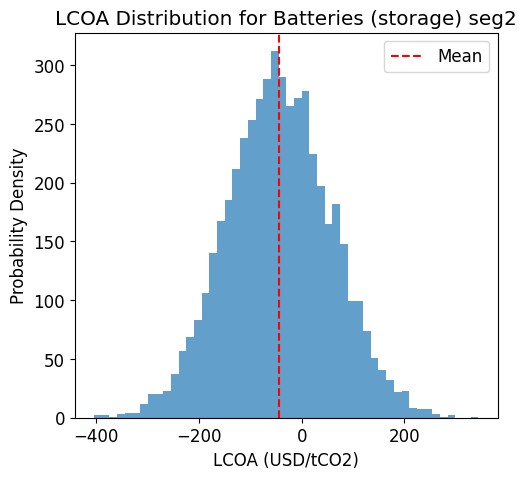

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copy MACC data into numpy arrays for fast math
potentials = MACC_data['segment_potential_MtCO2_per_year'].values
CAPEX_vals = MACC_data['CAPEX_USD_per_MtCO2'].values
OPEX_vals = MACC_data['OPEX_USD_per_year'].values
lifetimes = MACC_data['lifetime_years'].values
tech_names = MACC_data['technology'].values + " seg" + MACC_data['segment'].astype(str).values

#Monte Carlo Setting
n_iter = 5000
results_LCOA = []
results_revenue = []

def annualized_capex(capex, r, n):
  return capex * r * (1+r)**n / (( 1 +r)**n -1)

for i in range(n_iter):
    #sample variables
    capex_factor = np.random.normal(1, 0.2) #+- 20%
    carbon_price = np.random.normal(100, 100) #mean =100 , std 100
    discount_rate = np.random.normal(0.04, 0.07) # mean 10% sd = 10%
    discount_rate = max(discount_rate, 0.07) #avoid negatives ##NOT SURE THIS WORKS HERE

    #Vectorized calculations
    capex_total = CAPEX_vals * potentials * capex_factor
    annualized = annualized_capex(capex_total, discount_rate, lifetimes)
    annual_revenue = carbon_price * potentials
    annual_cost = OPEX_vals * potentials + annualized

    #Store results
    LCOA = (annual_cost - annual_revenue) / potentials
    revenue = annual_revenue

    results_LCOA.append(LCOA)
    results_revenue.append(revenue)

    # iter_data = []

    # for _, row in MACC_data.iterrows():
    #     capex_total = row['CAPEX_USD_per_MtCO2'] * row['segment_potential_MtCO2_per_year'] * capex_factor
    #     annualized = annualized_capex(capex_total, discount_rate, row['lifetime_years'])
    #     annual_revenue = carbon_price * row['segment_potential_MtCO2_per_year']
    #     annual_cost = MACC_data['annual_cost']

    #     LCOA_net = (annual_cost - annual_revenue)/row['segment_potential_MtCO2_per_year']

    #     iter_data.append(LCOA_net)

    # results.append(iter_data)

#Convert result to dataframe
#results_df = pd.DataFrame(results, columns=MACC_data['technology'] + 'seg' + MACC_data['segment'].astype(str))
LCOA_df = pd.DataFrame(results_LCOA, columns=tech_names)
Revenue_df = pd.DataFrame(results_revenue, columns=tech_names)

results_df = LCOA_df
#Summary statistics
print('=====Monte Carlo LCOA Results (USD/tCO2)=====')
print(results_df.describe(percentiles=[0.05, 0.5, 0.95]))
  #summary_stats = results_df.describe(percentiles=[0.05, 0.5, 0.95]).T

#Plot distribution for one example tech
tech_example=results_df.columns[0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(results_df[tech_example], bins=50, density=False, alpha=0.7)
plt.axvline(results_df[tech_example].mean(), color='r', linestyle='--', label='Mean')
plt.title(f'LCOA Distribution for {tech_example}')
plt.xlabel('LCOA (USD/tCO2)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

=====Monte Carlo LCOA Results (USD/tCO2)=====
       Batteries (storage) seg2  Batteries (storage) seg5  \
count               5000.000000               5000.000000   
mean               40919.057454              40919.057454   
std                40281.287511              40281.287511   
min              -111069.195331            -111069.195331   
5%                -25717.474843             -25717.474843   
50%                41423.317683              41423.317683   
95%               106597.549611             106597.549611   
max               176641.287723             176641.287723   

       Batteries (storage) seg4  Batteries (storage) seg3  \
count               5000.000000               5000.000000   
mean               40919.057454              40919.057454   
std                40281.287511              40281.287511   
min              -111069.195331            -111069.195331   
5%                -25717.474843             -25717.474843   
50%                41423.317683       

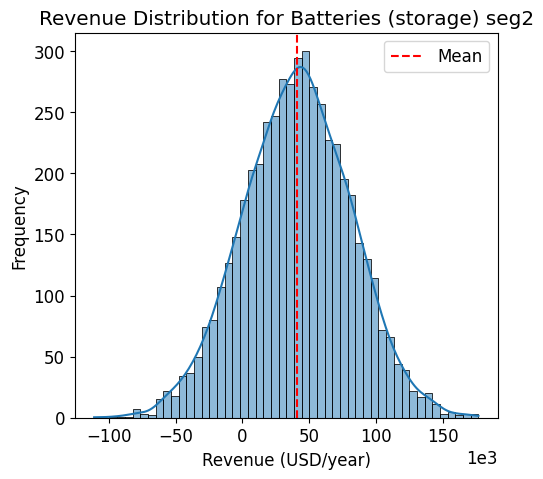

In [ ]:
import seaborn as sns

results_df = Revenue_df
#Summary statistics
print('=====Monte Carlo LCOA Results (USD/tCO2)=====')
print(results_df.describe(percentiles=[0.05, 0.5, 0.95]))
  #summary_stats = results_df.describe(percentiles=[0.05, 0.5, 0.95]).T

#Plot distribution for one example tech
tech_example=results_df.columns[0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(Revenue_df[tech_example], bins = 50, kde=True)
#plt.hist(results_df[tech_example], bins=50, density=False, alpha=0.7)
# plt.xscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3,3)) #scale by 10^3
plt.axvline(results_df[tech_example].mean(), color='r', linestyle='--', label='Mean')
plt.title(f'Revenue Distribution for {tech_example}')
plt.xlabel('Revenue (USD/year)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

<Axes: xlabel='Batteries (storage) seg2', ylabel='Count'>

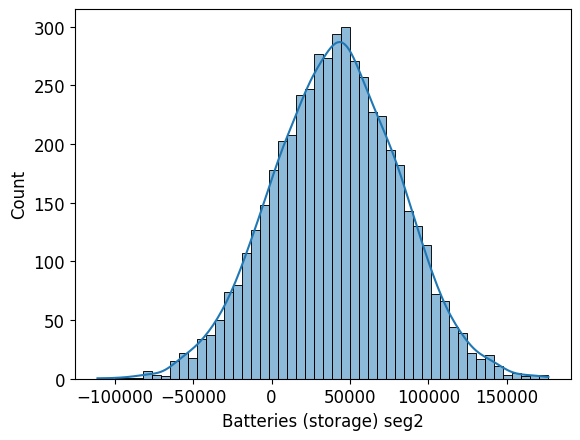

In [ ]:
import seaborn as sns
sns.histplot(Revenue_df[tech_example], bins = 50, kde=True)


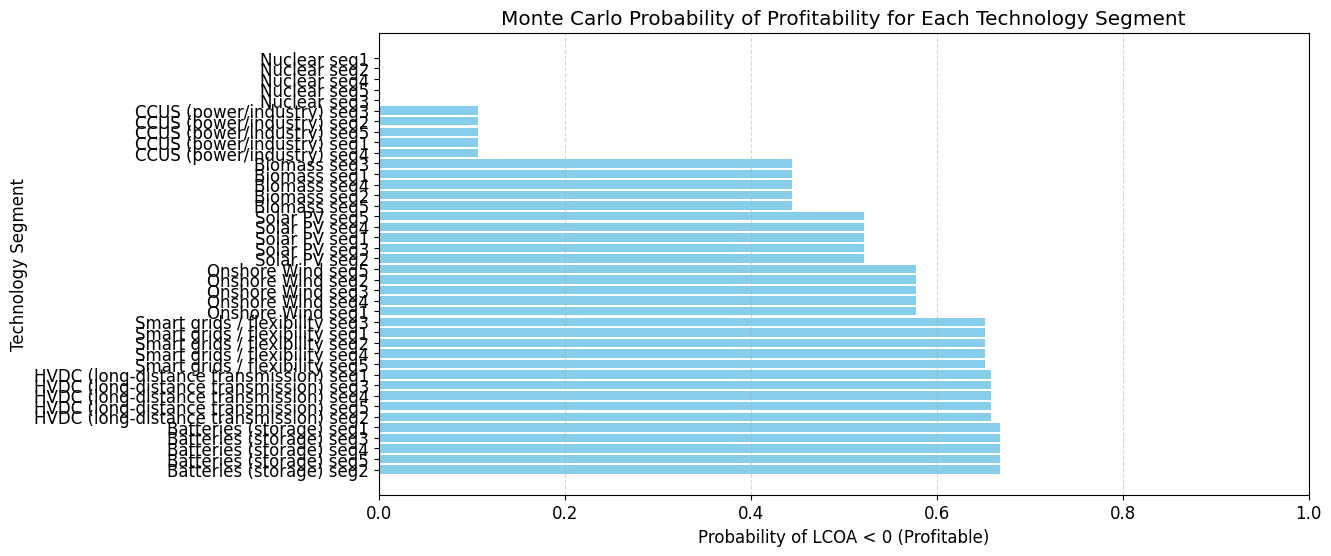

In [ ]:
#Chance of profitability - probability of LCOA<0 for each tech segment

#Calculate fraction of entries with LCOA<0 for each segment
profit_prob = (LCOA_df <0).mean(axis=0)

#Turn into dataframe
profit_prob_df = pd.DataFrame({
    'Tech Segment': profit_prob.index,
    'Profit_Prob': profit_prob.values
}).sort_values(by='Profit_Prob', ascending=False)

#profit_prob_df

#Visualise Profitability

plt.figure(figsize=(12,6))
plt.barh(profit_prob_df['Tech Segment'], profit_prob_df['Profit_Prob'], color='skyblue')
plt.xlabel("Probability of LCOA < 0 (Profitable)")
plt.ylabel("Technology Segment")
plt.title("Monte Carlo Probability of Profitability for Each Technology Segment")
plt.xlim(0,1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()



In [ ]:
#Dependence on market conditions
#Split simuations into low, medium, high carbon price
carbon_price_samples = np.random.normal(100, 100, n_iter)

low_mask=(carbon_price_samples<50)
med_mask=(carbon_price_samples >=50) & (carbon_price_samples <=100)
high_mask=carbon_price_samples >100

#Calculate LCOA <0 probability in each senario for each tech
tech_example = LCOA_df.columns[0] ###

low_prob = (LCOA_df[tech_example][low_mask] < 0).mean()
med_prob = (LCOA_df[tech_example][med_mask] < 0).mean()
high_prob = (LCOA_df[tech_example][high_mask] < 0).mean()

print(f"{tech_example} profitability probabilities:")
print(f"Low carbon price (<40 USD/tCO2): {low_prob:.2f}")
print(f"Medium carbon price (40-60 USD/tCO2): {med_prob:.2f}")
print(f"High carbon price (>60 USD/tCO2): {high_prob:.2f}")

Batteries (storage) seg2 profitability probabilities:
Low carbon price (<40 USD/tCO2): 0.66
Medium carbon price (40-60 USD/tCO2): 0.66
High carbon price (>60 USD/tCO2): 0.68


In [ ]:
import numpy as np
import pandas as pd

# Assume you have stored carbon price samples from Monte Carlo
# If not, resample here:
n_iter = LCOA_df.shape[0]
carbon_price_samples = np.random.normal(100, 100, n_iter)

# Define scenarios
low_mask = carbon_price_samples < 50
med_mask = (carbon_price_samples >= 50) & (carbon_price_samples <= 100)
high_mask = carbon_price_samples > 100

# Prepare table
tech_list = LCOA_df.columns[:10]  # first 10 technologies
profit_table = []

for tech in tech_list:
    low_prob = (LCOA_df[tech][low_mask] < 0).mean()
    med_prob = (LCOA_df[tech][med_mask] < 0).mean()
    high_prob = (LCOA_df[tech][high_mask] < 0).mean()

    profit_table.append({
        'Technology_Segment': tech,
        'LowCarbonPrice(<40)': low_prob,
        'MediumCarbonPrice(40-60)': med_prob,
        'HighCarbonPrice(>60)': high_prob
    })

profit_df = pd.DataFrame(profit_table)

# Display table
profit_df


,Technology_Segment,LowCarbonPrice(<40),MediumCarbonPrice(40-60),HighCarbonPrice(>60)
0,Batteries (storage) seg2,0.681254,0.653886,0.666134
1,Batteries (storage) seg5,0.681254,0.653886,0.666134
2,Batteries (storage) seg4,0.681254,0.653886,0.666134
3,Batteries (storage) seg3,0.681254,0.653886,0.666134
4,Batteries (storage) seg1,0.681254,0.653886,0.666134
5,Biomass seg2,0.463749,0.436269,0.436102
6,Biomass seg4,0.463749,0.436269,0.436102
7,Biomass seg5,0.463749,0.436269,0.436102
8,Biomass seg1,0.463749,0.436269,0.436102
9,Biomass seg3,0.463749,0.436269,0.436102


In [ ]:
# #Discounted Cash Flow model
# import numpy as np

# def dcf(opex, revenue, time):
#     years = np.linspace(0, time, time)
#     free_cf = revenue - opex
#     cf_pv = []

#     for year in years:
#       pv = discounting(free_cf, year)
#       cf_pv.append(pv)

#     total_cf = sum(cf_pv)

#     return total_cf

# iea_data['Cash Flow 20 Yrs Mean']= -iea_data['Overnight costs (USD/kWe) Mean']*1000 + dcf(opex=iea_data['OPEX (USD/kWe) Mean'],
#                                 revenue=iea_data['Revenue ($) Mean'],
#                                 time=20)

# #time - assume a 20 years time horizon
